# 可视化训练日志-训练过程训练集各类别评估指标

训练模型时在`work_dirs`目录生成记录训练日志，解析其中损失函数、评估指标等信息，并可视化。

同济子豪兄：https://space.bilibili.com/1900783

## 设置Matplotlib中文字体

In [1]:
# # windows操作系统
# plt.rcParams['font.sans-serif']=['SimHei']  # 用来正常显示中文标签 
# plt.rcParams['axes.unicode_minus']=False  # 用来正常显示负号

In [2]:
# Mac操作系统，参考 https://www.ngui.cc/51cto/show-727683.html
# 下载 simhei.ttf 字体文件
# !wget https://zihao-openmmlab.obs.cn-east-3.myhuaweicloud.com/20220716-mmclassification/dataset/SimHei.ttf

In [1]:
# Linux操作系统，例如 云GPU平台：https://featurize.cn/?s=d7ce99f842414bfcaea5662a97581bd1
# 如果遇到 SSL 相关报错，重新运行本代码块即可
# !wget https://zihao-openmmlab.obs.cn-east-3.myhuaweicloud.com/20220716-mmclassification/dataset/SimHei.ttf -O /environment/miniconda3/lib/python3.7/site-packages/matplotlib/mpl-data/fonts/ttf/SimHei.ttf
# !rm -rf /home/featurize/.cache/matplotlib

import matplotlib 
import matplotlib.pyplot as plt
matplotlib.rc("font",family='SimHei') # 中文字体


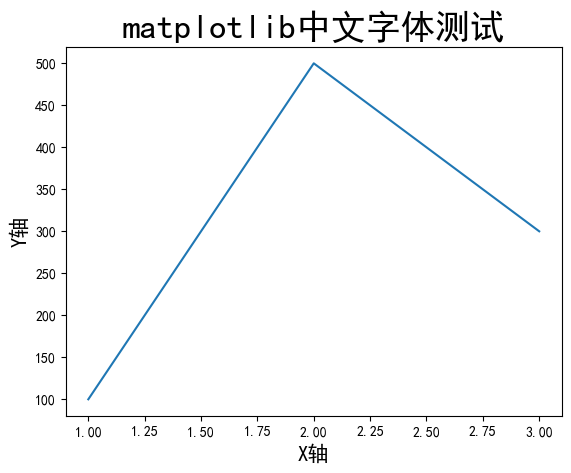

In [2]:
plt.plot([1,2,3], [100,500,300])
plt.title('matplotlib中文字体测试', fontsize=25)
plt.xlabel('X轴', fontsize=15)
plt.ylabel('Y轴', fontsize=15)
plt.show()

## 可视化辅助函数

In [3]:
from matplotlib import colors as mcolors
import random
random.seed(124)
colors = ['b', 'g', 'r', 'c', 'm', 'y', 'k', 'tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple', 'tab:brown', 'tab:pink', 'tab:gray', 'tab:olive', 'tab:cyan', 'black', 'indianred', 'brown', 'firebrick', 'maroon', 'darkred', 'red', 'sienna', 'chocolate', 'yellow', 'olivedrab', 'yellowgreen', 'darkolivegreen', 'forestgreen', 'limegreen', 'darkgreen', 'green', 'lime', 'seagreen', 'mediumseagreen', 'darkslategray', 'darkslategrey', 'teal', 'darkcyan', 'dodgerblue', 'navy', 'darkblue', 'mediumblue', 'blue', 'slateblue', 'darkslateblue', 'mediumslateblue', 'mediumpurple', 'rebeccapurple', 'blueviolet', 'indigo', 'darkorchid', 'darkviolet', 'mediumorchid', 'purple', 'darkmagenta', 'fuchsia', 'magenta', 'orchid', 'mediumvioletred', 'deeppink', 'hotpink']
markers = [".",",","o","v","^","<",">","1","2","3","4","8","s","p","P","*","h","H","+","x","X","D","d","|","_",0,1,2,3,4,5,6,7,8,9,10,11]
linestyle = ['--', '-.', '-']

def get_line_arg():
    '''
    随机产生一种绘图线型
    '''
    line_arg = {}
    line_arg['color'] = random.choice(colors)
    # line_arg['marker'] = random.choice(markers)
    line_arg['linestyle'] = random.choice(linestyle)
    line_arg['linewidth'] = random.randint(1, 4)
    # line_arg['markersize'] = random.randint(3, 5)
    return line_arg

## 进入MMSegmentation主目录

In [4]:
# import os
# os.chdir('mmsegmentation')

import os
# 假设 mmsegmentation 的绝对路径是 /project/mmsegmentation
mmsegmentation_path = "E:/bishe_custom_data/mmsegmentation-main"
# 切换到 mmsegmentation 文件夹
os.chdir(mmsegmentation_path)
# 验证当前工作目录
print("当前工作目录:", os.getcwd())  # 输出: /project/mmsegmentation

当前工作目录: E:\bishe_custom_data\mmsegmentation-main


In [5]:
os.getcwd()

'E:\\bishe_custom_data\\mmsegmentation-main'

## 导入工具包

In [5]:
import pandas as pd

import matplotlib.pyplot as plt
%matplotlib inline

## 类别列表

In [6]:
# # 类别列表
# class_list = ['background', 'red', 'green', 'white', 'seed-black', 'seed-white']

class_list = ['background', 'person', 'roadheader', 'robot', 'shearer']

## 载入日志文件

In [7]:
# 日志文件路径
log_path = './work_dirs/ZihaoDataset-DeepLabV3plus/20250317_111401/20250317_111401.log'

In [8]:
with open(log_path, 'r') as f:
    logs = f.read()

In [9]:
## 定义正则表达式
import re
import numpy as np

def transform_table_line(raw):
    raw = list(map(lambda x: x.split('|'), raw))
    raw = list(map(
      lambda row: list(map(
          lambda col: float(col.strip()),
          row
      )),
      raw
    ))
    return raw

## 横轴-训练迭代次数

In [10]:
# x = range(500, 40500, 500)#

x = range(100, 5100, 100)

In [11]:
len(x)

50

## 定义正则表达式

In [12]:
metrics_json = {}
for each_class in class_list: # 遍历每个类别
    re_pattern = r'\s+{}.*?\|(.*)?\|'.format(each_class) # 定义该类别的正则表达式
    metrics_json[each_class] = {}
    metrics_json[each_class]['re_pattern'] = re.compile(re_pattern)

In [13]:
# 匹配
for each_class in class_list: # 遍历每个类别
    find_string = re.findall(metrics_json[each_class]['re_pattern'], logs) # 粗匹配
    find_string = transform_table_line(find_string) # 精匹配
    metrics_json[each_class]['metrics'] = find_string

In [14]:
metrics_json.keys()

dict_keys(['background', 'person', 'roadheader', 'robot', 'shearer'])

## 查看某一类别的评估指标 IoU Acc Dice Fscore Precision Recall

In [15]:
# each_class = 'red'
# each_class_metrics = np.array(metrics_json[each_class]['metrics'])

each_class = 'person'
each_class_metrics = np.array(metrics_json[each_class]['metrics'])

In [16]:
metrics_json[each_class]['metrics']

[[6.82, 22.57, 12.76, 12.76, 8.9, 22.57],
 [11.75, 14.83, 21.03, 21.03, 36.14, 14.83],
 [12.11, 13.47, 21.61, 21.61, 54.65, 13.47],
 [24.4, 24.9, 39.22, 39.22, 92.37, 24.9],
 [27.98, 58.5, 43.72, 43.72, 34.9, 58.5],
 [33.99, 65.07, 50.73, 50.73, 41.57, 65.07],
 [15.51, 17.44, 26.86, 26.86, 58.41, 17.44],
 [34.75, 46.27, 51.57, 51.57, 58.26, 46.27],
 [21.41, 31.97, 35.27, 35.27, 39.33, 31.97],
 [42.35, 58.68, 59.5, 59.5, 60.34, 58.68],
 [38.41, 66.18, 55.5, 55.5, 47.79, 66.18],
 [19.01, 22.05, 31.95, 31.95, 58.01, 22.05],
 [28.84, 58.24, 44.76, 44.76, 36.35, 58.24],
 [30.0, 77.15, 46.16, 46.16, 32.93, 77.15],
 [44.41, 58.27, 61.51, 61.51, 65.14, 58.27],
 [35.1, 76.39, 51.97, 51.97, 39.38, 76.39],
 [42.12, 61.64, 59.28, 59.28, 57.09, 61.64],
 [44.51, 61.41, 61.6, 61.6, 61.79, 61.41],
 [31.55, 79.69, 47.96, 47.96, 34.31, 79.69],
 [48.34, 70.26, 65.18, 65.18, 60.78, 70.26],
 [36.85, 79.14, 53.86, 53.86, 40.82, 79.14],
 [45.54, 53.5, 62.58, 62.58, 75.37, 53.5],
 [23.3, 27.42, 37.79, 37.79, 

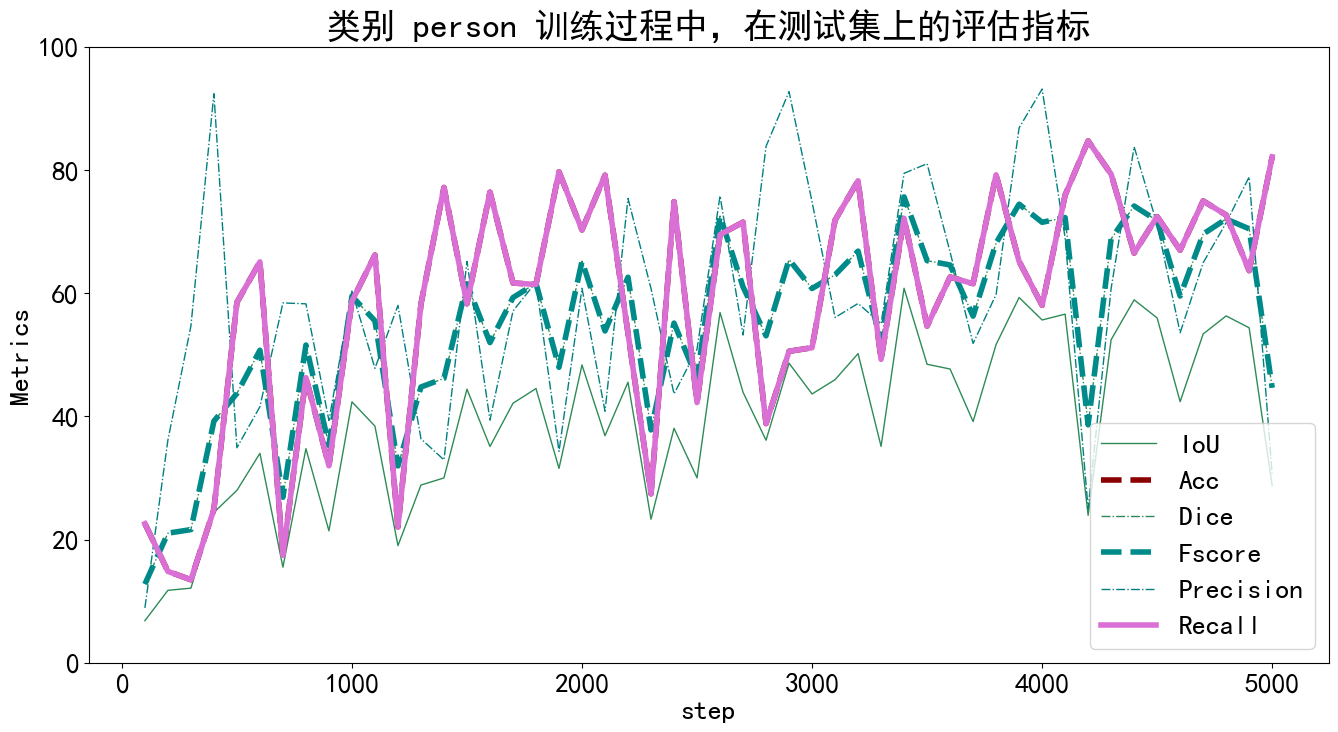

In [17]:
# plt.figure(figsize=(16, 8))
# 
# for idx, each_metric in enumerate(['IoU', 'Acc', 'Dice', 'Fscore', 'Precision', 'Recall']):
# 
#     try:
#         plt.plot(x, each_class_metrics[:,idx], label=each_metric, **get_line_arg())
#     except:
#         pass
# 
# plt.tick_params(labelsize=20)
# plt.ylim([0, 100])
# plt.xlabel('step', fontsize=20)
# plt.ylabel('Metrics', fontsize=20)
# plt.title('类别 {} 训练过程中，在测试集上的评估指标'.format(each_class), fontsize=25)
# 
# plt.legend(fontsize=20)
# 
# plt.savefig('图表/类别 {} 训练过程评估指标.pdf'.format(each_class), dpi=120, bbox_inches='tight')
# 
# plt.show()

plt.figure(figsize=(16, 8))

for idx, each_metric in enumerate(['IoU', 'Acc', 'Dice', 'Fscore', 'Precision', 'Recall']):

    try:
        plt.plot(x, each_class_metrics[:,idx], label=each_metric, **get_line_arg())
    except:
        pass

plt.tick_params(labelsize=20)
plt.ylim([0, 100])
plt.xlabel('step', fontsize=20)
plt.ylabel('Metrics', fontsize=20)
plt.title('类别 {} 训练过程中，在测试集上的评估指标'.format(each_class), fontsize=25)

plt.legend(fontsize=20)

plt.savefig('图表/类别 {} 训练过程评估指标.pdf'.format(each_class), dpi=120, bbox_inches='tight')

plt.show()

## x的元素个数，应和`metrics_json[each_class]['metrics']`元素个数一致，绘图才能成功

## 查看每个类别的评估指标 IoU Acc Dice Fscore Precision Recall

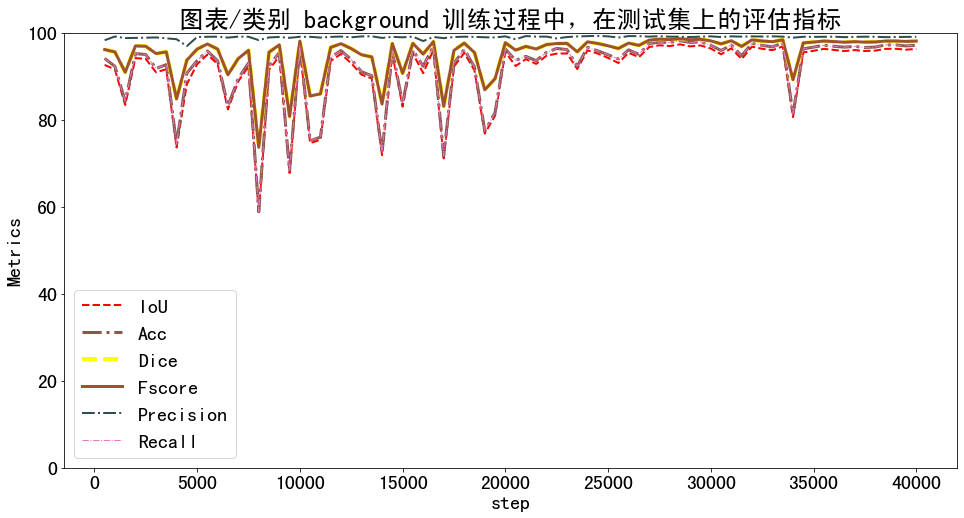

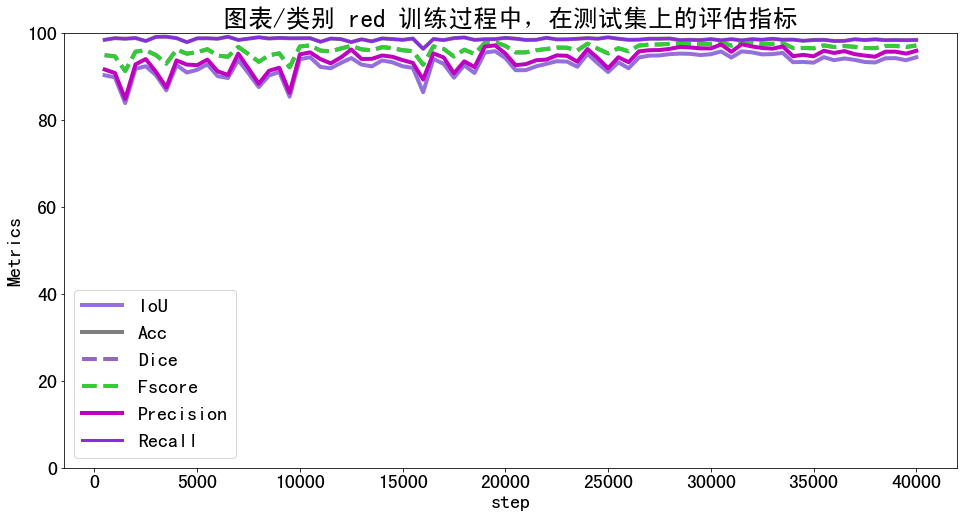

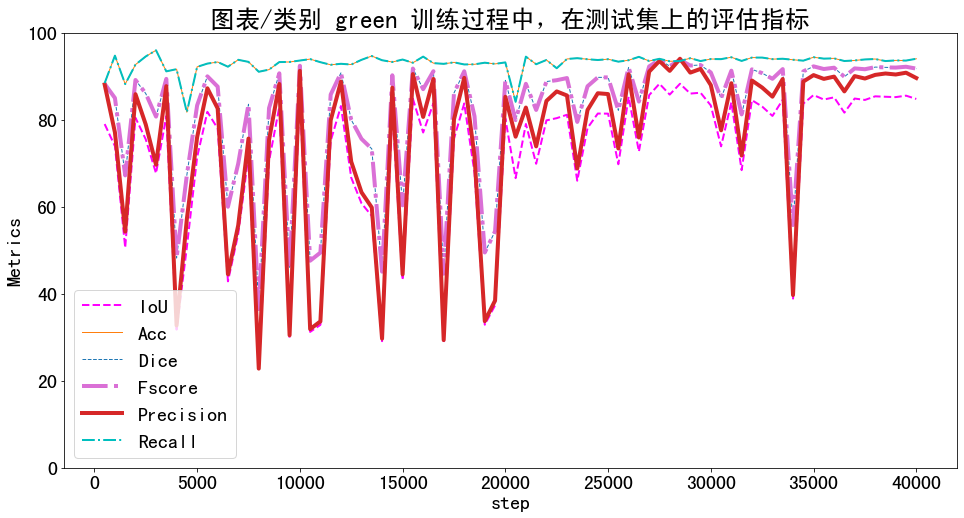

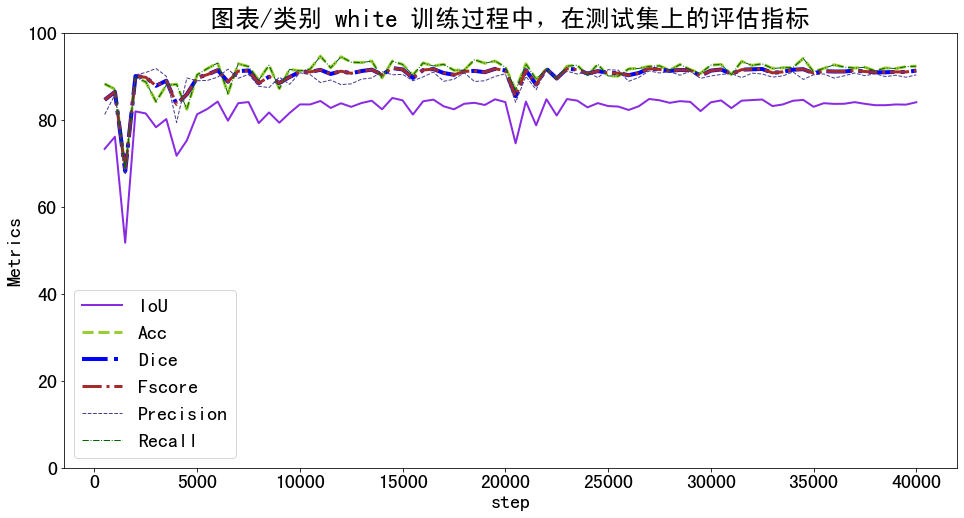

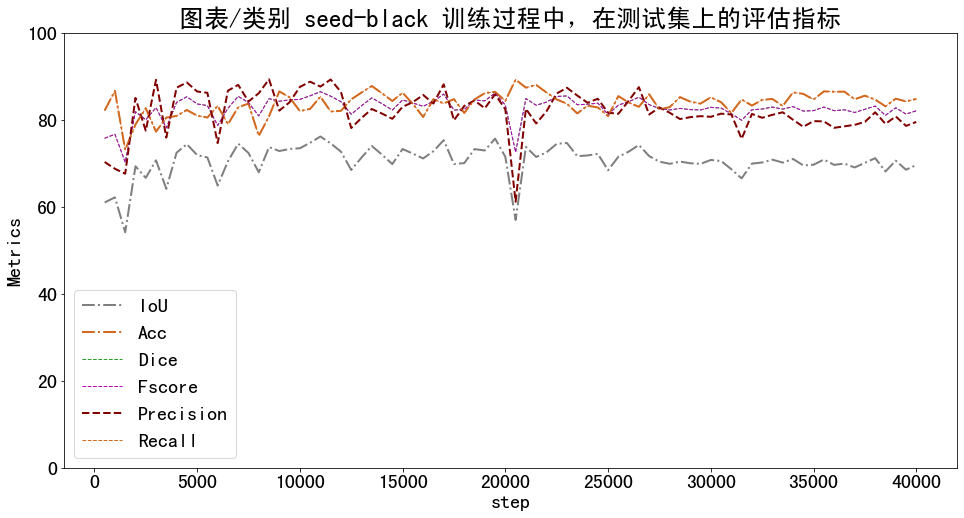

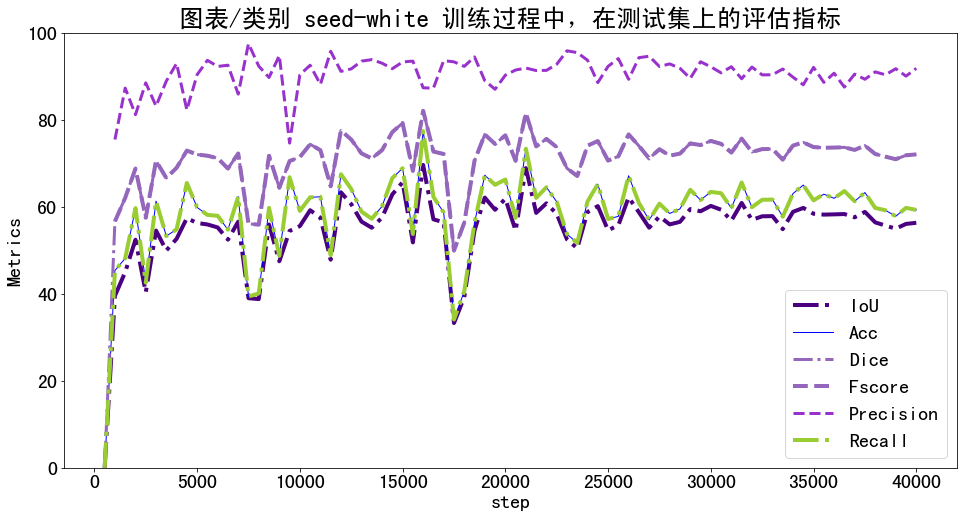

In [23]:
#我的在下一个代码单元格中


# for each_class in class_list: # 遍历每个类别
#     each_class_metrics = np.array(metrics_json[each_class]['metrics'])
#     
#     plt.figure(figsize=(16, 8))
# 
#     for idx, each_metric in enumerate(['IoU', 'Acc', 'Dice', 'Fscore', 'Precision', 'Recall']):
# 
#         try:
#             plt.plot(x, each_class_metrics[:,idx], label=each_metric, **get_line_arg())
#         except:
#             pass
# 
#     plt.tick_params(labelsize=20)
#     plt.ylim([0, 100])
#     plt.xlabel('step', fontsize=20)
#     plt.ylabel('Metrics', fontsize=20)
#     plt.title('图表/类别 {} 训练过程中，在测试集上的评估指标'.format(each_class), fontsize=25)
# 
#     plt.legend(fontsize=20)
# 
#     # plt.savefig('类别 {} 训练过程评估指标.pdf'.format(each_class), dpi=120, bbox_inches='tight')
# 
#     plt.show()

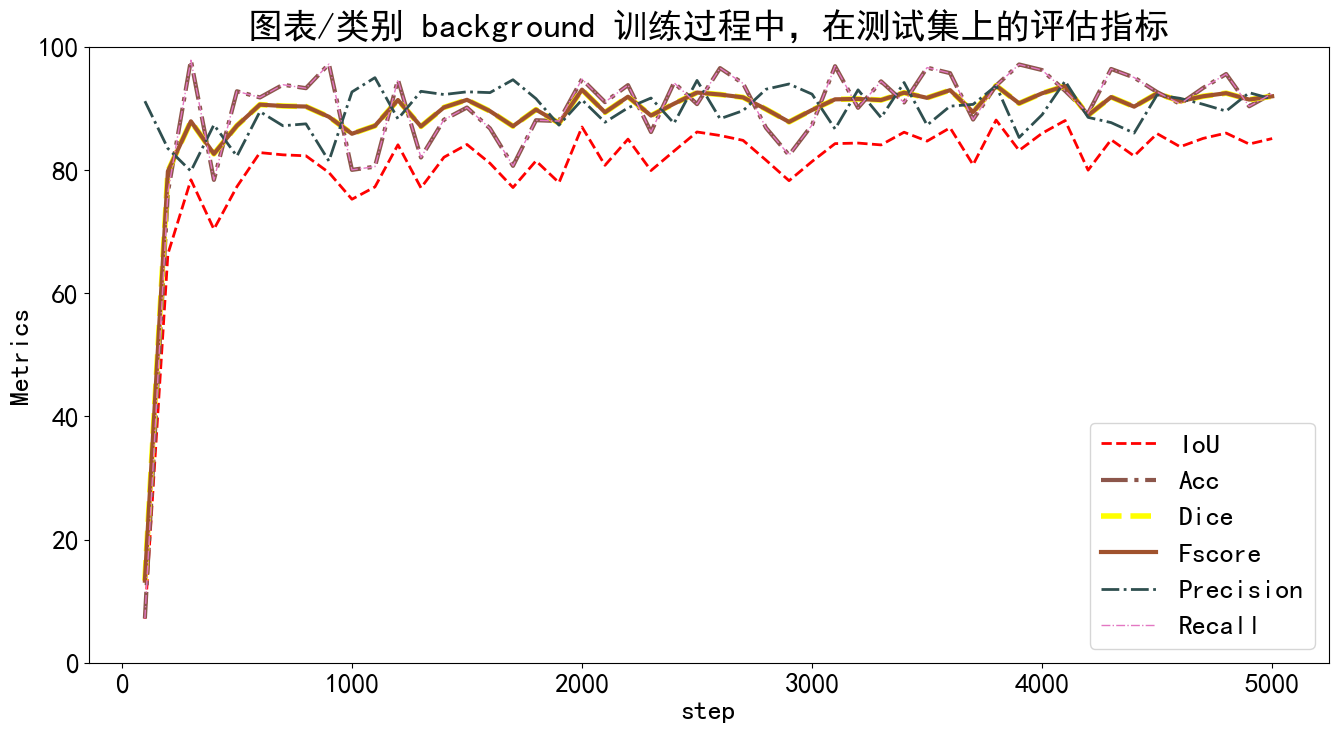

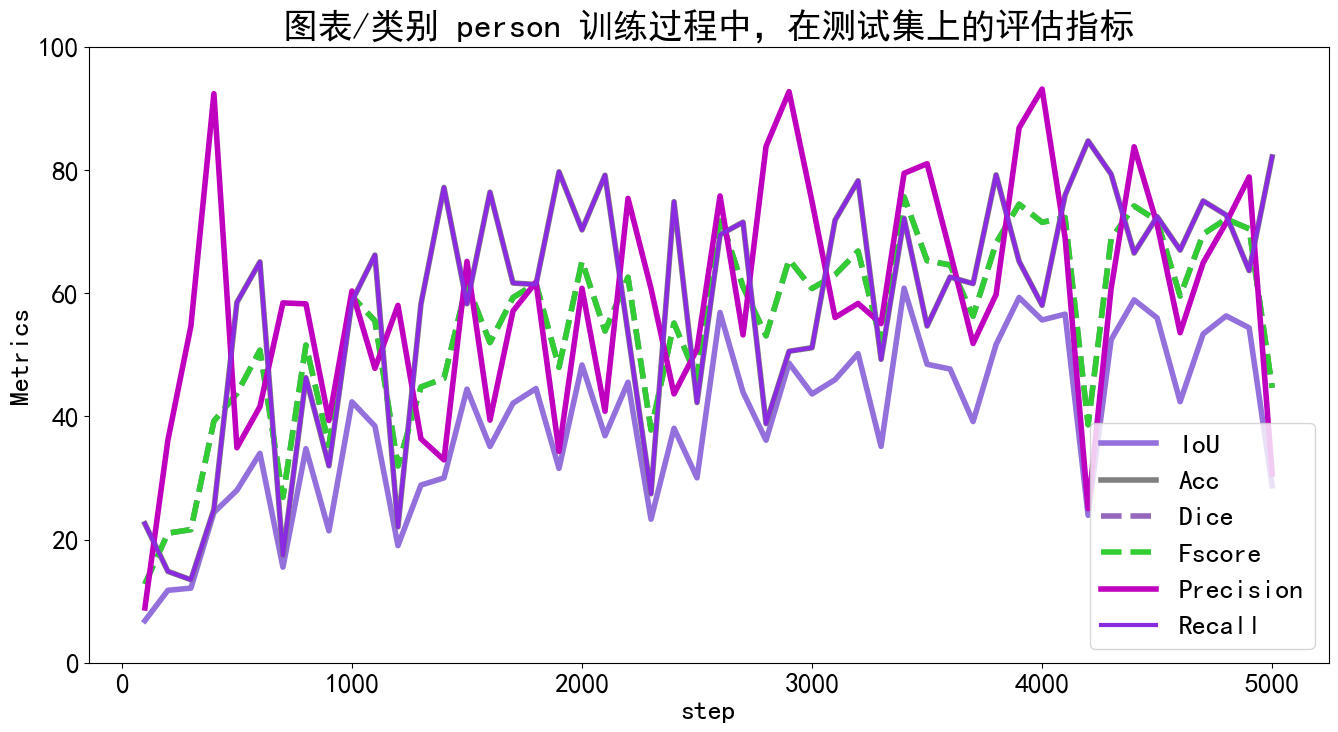

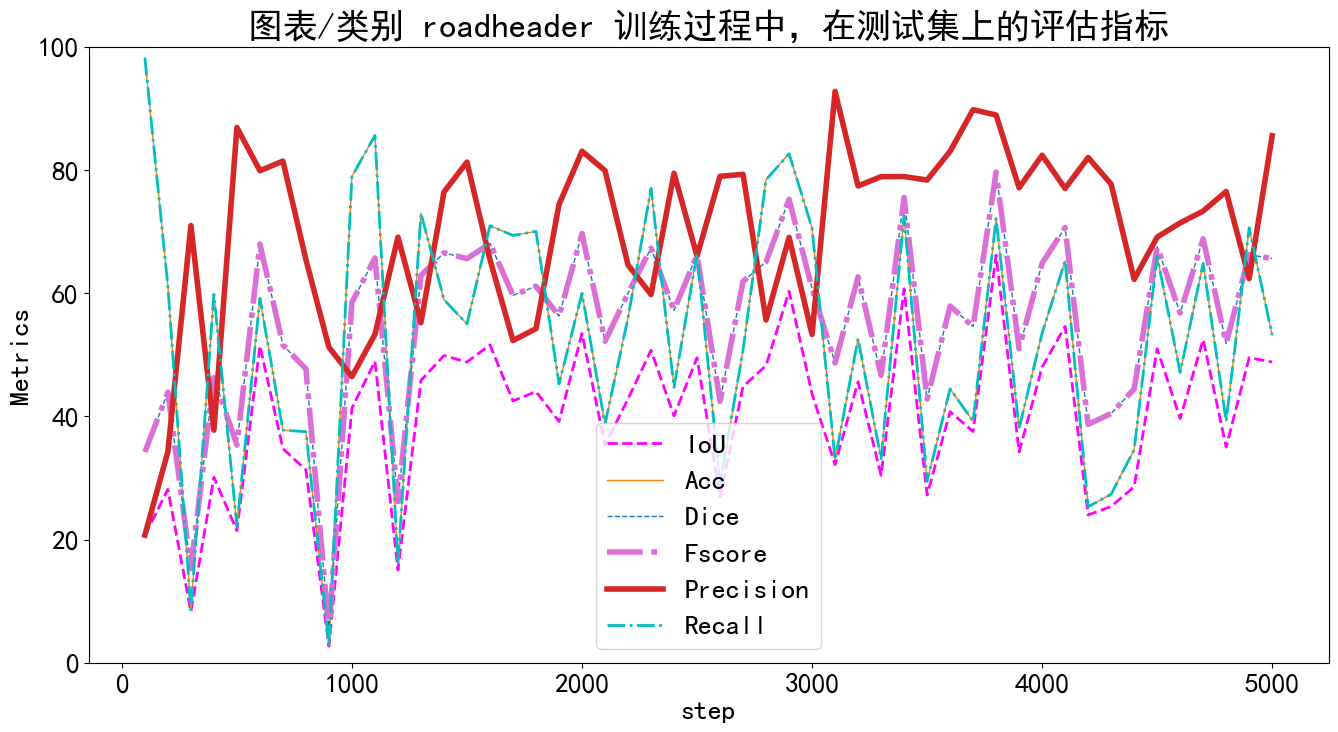

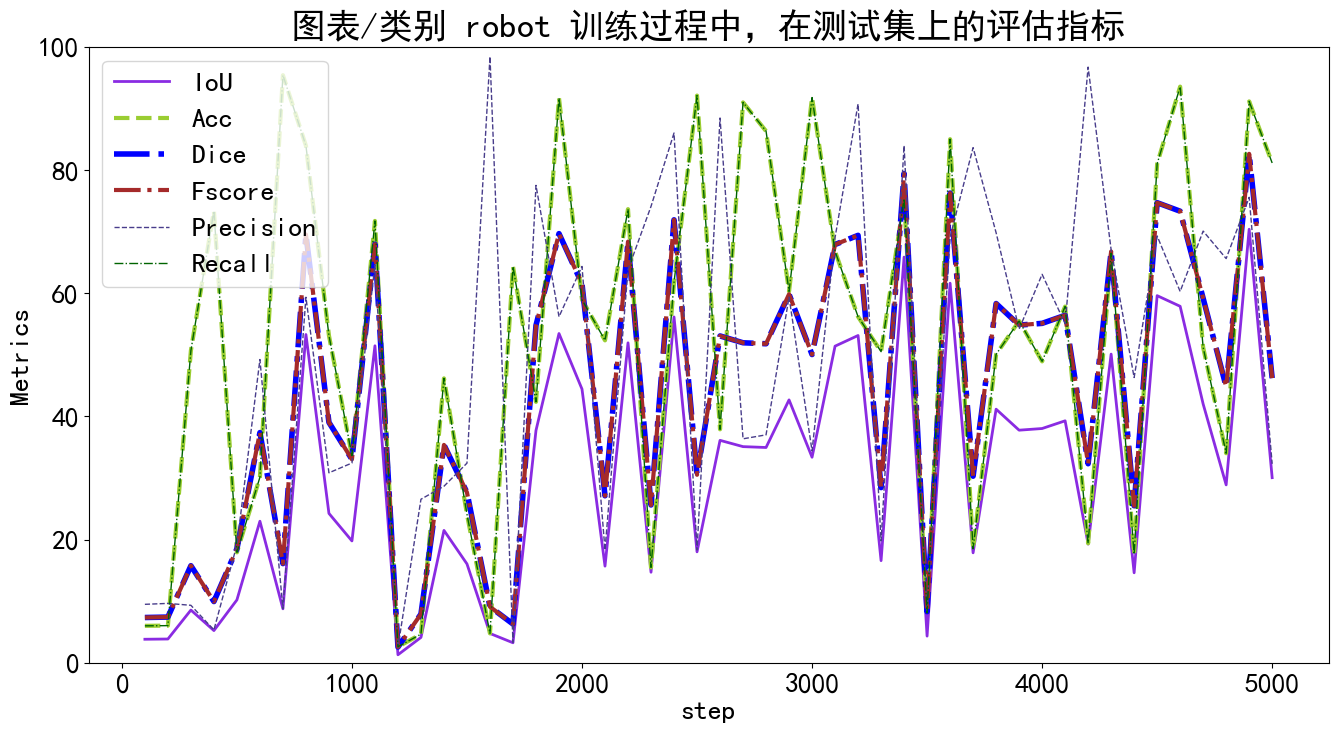

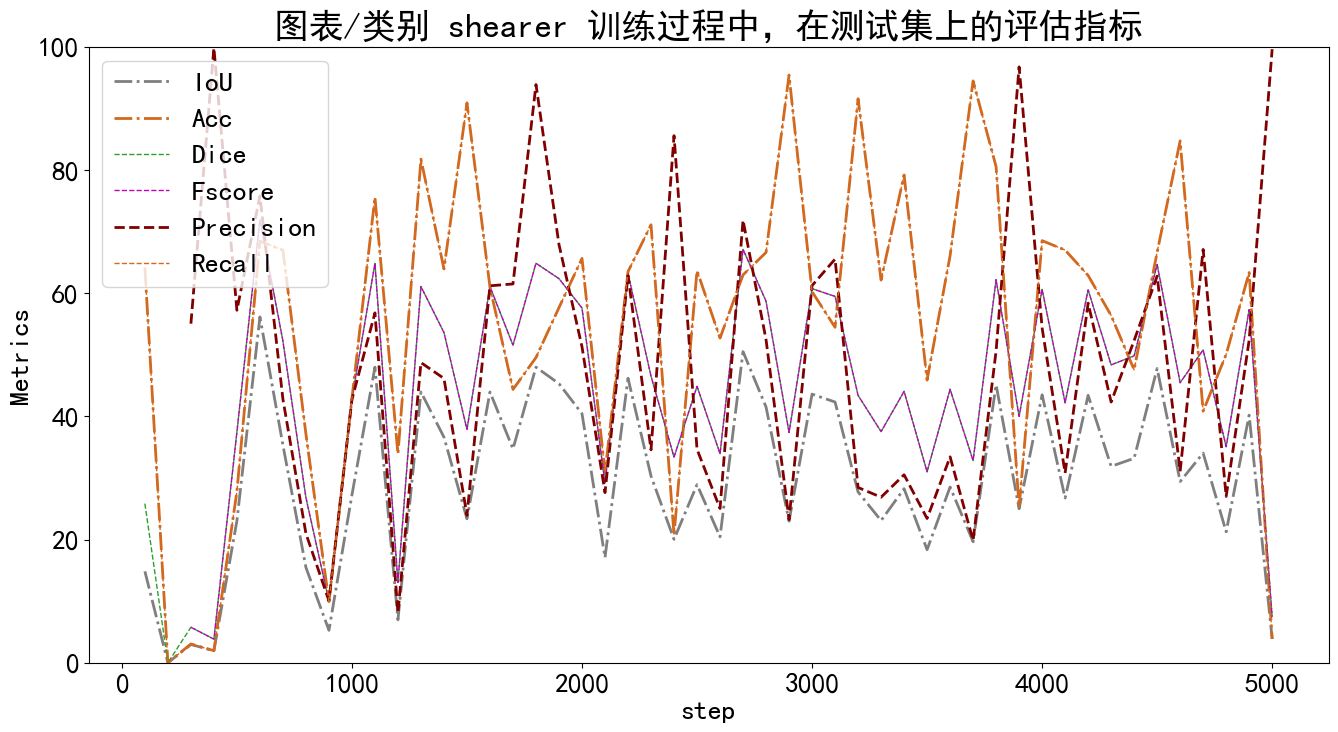

In [18]:
for each_class in class_list: # 遍历每个类别
    each_class_metrics = np.array(metrics_json[each_class]['metrics'])
    
    plt.figure(figsize=(16, 8))

    for idx, each_metric in enumerate(['IoU', 'Acc', 'Dice', 'Fscore', 'Precision', 'Recall']):

        try:
            plt.plot(x, each_class_metrics[:,idx], label=each_metric, **get_line_arg())
        except:
            pass

    plt.tick_params(labelsize=20)
    plt.ylim([0, 100])
    plt.xlabel('step', fontsize=20)
    plt.ylabel('Metrics', fontsize=20)
    plt.title('图表/类别 {} 训练过程中，在测试集上的评估指标'.format(each_class), fontsize=25)

    plt.legend(fontsize=20)

    # plt.savefig('类别 {} 训练过程评估指标.pdf'.format(each_class), dpi=120, bbox_inches='tight')

    plt.show()